# PROBLEM STATEMENT
The dataset under consideration comprises various features, including Country, GDP per capita, and Generosity. The primary objectives of this analysis   are to address the following questions:  

Which factors exhibit a correlation with happiness?  
How has the level of happiness changed over time?  

Furthermore, this study seeks to conduct a comparative analysis of well-being metrics at a global scale to derive meaningful insights and trends.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv('world_happiness_report.csv')
df

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


## DATA CLEANING:

In [5]:
df.dtypes

Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

Here, all the columns have correct datatype.

In [7]:
df.isnull().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

In [8]:
contain_nan = df['Score'].isnull().any()
print(contain_nan)

False


There is no missing or null values.

### Dropping irrelevant columns

In [11]:
df.drop(columns=['Overall rank'],inplace=True)

## EDA[Exploratory Data Analysis]

In [13]:
df.head()

,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [14]:
df.tail()

,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
151,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
155,South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091


In [15]:
df.shape

(156, 8)

In [16]:
df.describe(include='all')

,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
unique,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Finland,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,NaN,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,NaN,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,NaN,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,NaN,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250


In [17]:
df.describe(include='object')

,Country or region
count,156
unique,156
top,Finland
freq,1


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country or region             156 non-null    object 
 1   Score                         156 non-null    float64
 2   GDP per capita                156 non-null    float64
 3   Social support                156 non-null    float64
 4   Healthy life expectancy       156 non-null    float64
 5   Freedom to make life choices  156 non-null    float64
 6   Generosity                    156 non-null    float64
 7   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.9+ KB


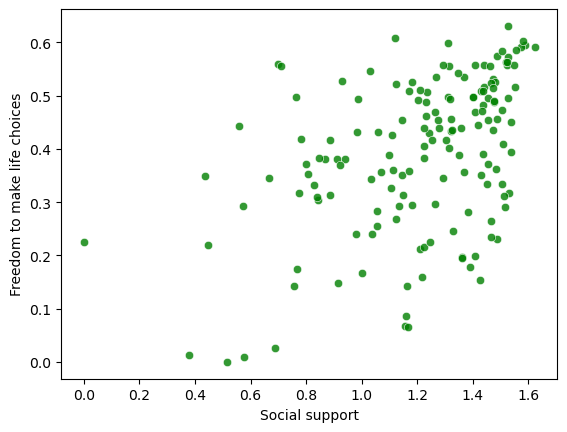

In [19]:
sns.scatterplot(data=df,x='Social support',y='Freedom to make life choices',alpha=0.8,color='green')
plt.savefig('happiness1.png')

We can see here clearly that, 'social support' is directly proportional to 'Freedom to make life choices'.

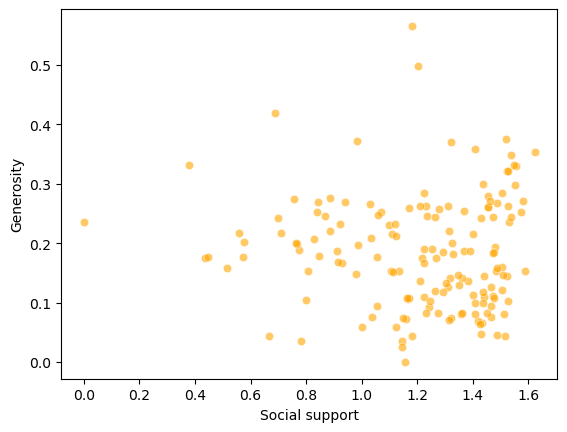

In [21]:
sns.scatterplot(data=df,x='Social support',y='Generosity',alpha=0.6,color='orange')
plt.savefig('happiness2.png')

Here, the conclusion is if the Social support is more then generosity exists more.

In [23]:
df[['Social support','Freedom to make life choices','Generosity']].corr()

,Social support,Freedom to make life choices,Generosity
Social support,1.000000,0.447333,-0.048126
Freedom to make life choices,0.447333,1.000000,0.269742
Generosity,-0.048126,0.269742,1.000000


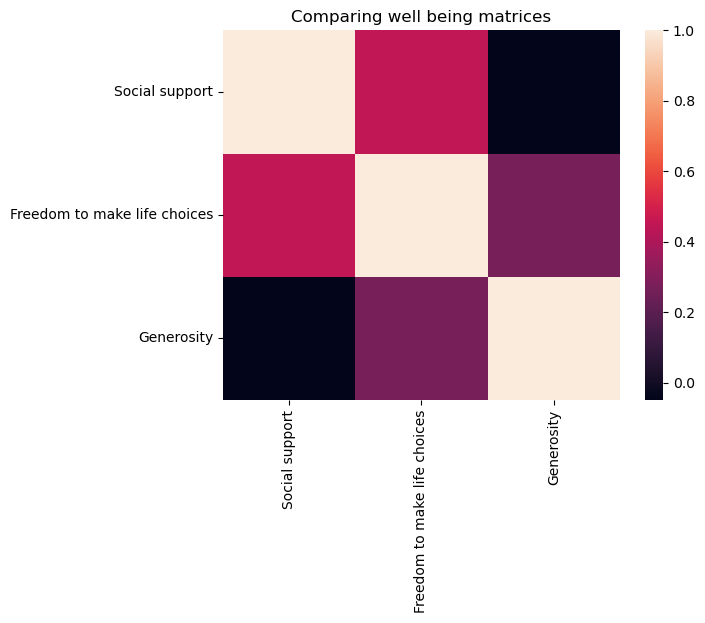

In [71]:
sns.heatmap(df[['Social support','Freedom to make life choices','Generosity']].corr())
plt.title('Comparing well being matrices')
plt.savefig('happiness3.png',bbox_inches = 'tight')

From this heatmap it is clear that 'Freedom to make life choices' is less correlated to 'Generosity' rather it is more correlated with 'Socail support'. Meanwhile 'Social support' and 'Generosity' is not at all correlated to each other.

### Factors correlate with happiness

The best way we can do this is with the use of a heatmap.

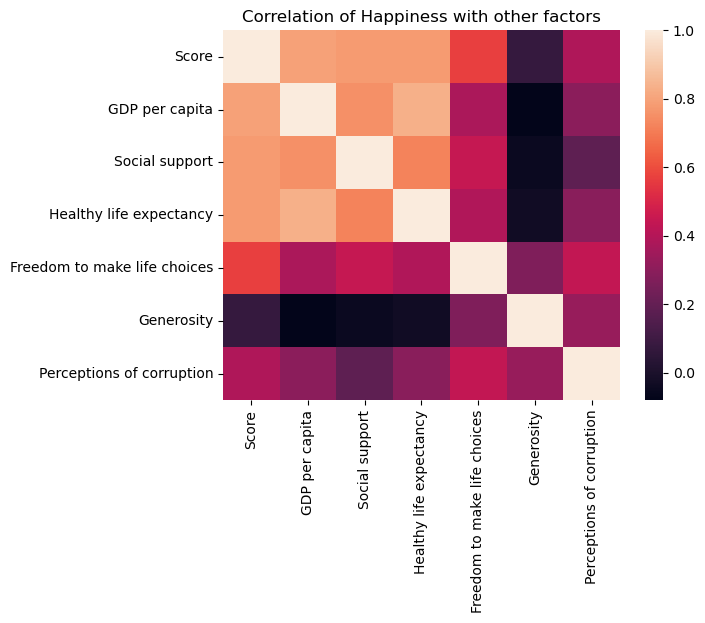

In [67]:
sns.heatmap(df[['Score','GDP per capita','Social support','Healthy life expectancy','Freedom to make life choices','Generosity','Perceptions of corruption']].corr())
plt.title('Correlation of Happiness with other factors')
plt.savefig('happiness4.png',bbox_inches = 'tight')

Here in the above heatmap we can see, the factors which correlates with happiness are 'GDP peer capita', 'Social support' and 'Healthy life expectency'.

In [30]:
df_2015=pd.read_csv(r"C:\Users\KARTIK\Music\Nokia Project_1\world_happiness\2015.csv")
df_2015['Year'] = 2015
df_2016=pd.read_csv(r"C:\Users\KARTIK\Music\Nokia Project_1\world_happiness\2016.csv")
df_2016['Year'] = 2016
df_2017=pd.read_csv(r"C:\Users\KARTIK\Music\Nokia Project_1\world_happiness\2017.csv")
df_2017['Year'] = 2017
df_2018=pd.read_csv(r"C:\Users\KARTIK\Music\Nokia Project_1\world_happiness\2018.csv")
df_2018['Year'] = 2018
df_2019=pd.read_csv(r"C:\Users\KARTIK\Music\Nokia Project_1\world_happiness\2019.csv")
df_2019['Year'] = 2019


In [31]:
df_2017.rename(columns={'Score': 'Happiness Score'}, inplace=True)
df_2018.rename(columns={'Score': 'Happiness Score'}, inplace=True)
df_2019.rename(columns={'Score': 'Happiness Score'}, inplace=True)

In [32]:
df_merged=pd.concat([df_2015,df_2016,df_2017,df_2018,df_2019],ignore_index=True)
df_merged

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,Health..Life.Expectancy.,Trust..Government.Corruption.,Dystopia.Residual,Overall rank,Country or region,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,NaN,NaN,NaN,3.334,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,152.0,Rwanda,0.359,0.711,0.614,0.555,0.411
778,NaN,NaN,NaN,3.231,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,153.0,Tanzania,0.476,0.885,0.499,0.417,0.147
779,NaN,NaN,NaN,3.203,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,154.0,Afghanistan,0.350,0.517,0.361,0.000,0.025
780,NaN,NaN,NaN,3.083,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,155.0,Central African Republic,0.026,0.000,0.105,0.225,0.035


In [33]:
contains_nan = df_merged['Happiness Score'].isnull().any()
print(contains_nan)

True


Since there are NaN values in the 'Happiness Score' column, so first we will resolve this despirency by removing the nan values.

In [35]:
df_merged=df_merged.dropna(subset='Happiness Score')
df_merged.dtypes

Country                           object
Region                            object
Happiness Rank                   float64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
Year                               int64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Happiness.Rank                   float64
Happiness.Score                  float64
Whisker.high                     float64
Whisker.low                      float64
Economy..GDP.per.Capita.         float64
Health..Life.Expectancy.         float64
Trust..Government.Corruption.    float64
Dystopia.Residual                float64
Overall rank                     float64
Country or regio

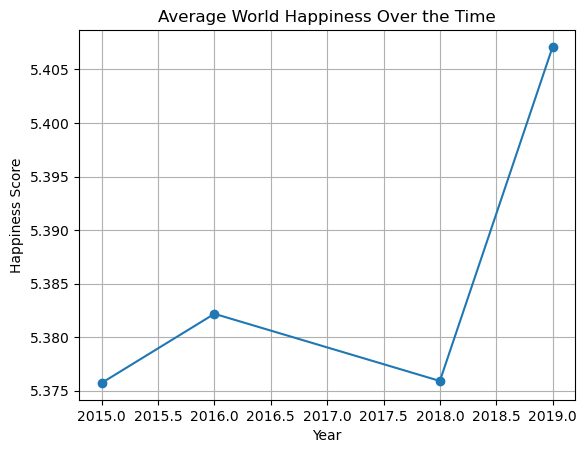

In [75]:
avg_happiness_per_year = df_merged.groupby('Year')['Happiness Score'].mean().reset_index()
plt.plot(avg_happiness_per_year['Year'], avg_happiness_per_year['Happiness Score'], marker='o')
plt.title('Average World Happiness Over the Time')
plt.xlabel('Year')
plt.ylabel('Happiness Score')
plt.grid(True)
plt.savefig('happiness5.png',bbox_inches='tight')
plt.show()


Here, we can see the score was lowest in 2015 then increased in 2016 then again went down in 2018 but after 2018 it exponentially increased and gone highest as never before in 2019.

## Final analasys

1) From the heatmap it is clear that 'Freedom to make life choices' is less correlated to 'Generosity' rather it is more correlated with 'Socail support'. Meanwhile 'Social support' and 'Generosity' is not at all correlated to each other.
2) From the heatmap we can see, the factors which correlates with happiness are 'GDP peer capita', 'Social support' and 'Healthy life expectency'.
3) The happiness score was lowest in 2015 then increased in 2016 then again went down in 2018 but after 2018 it exponentially increased and gone highest as never before in 2019.